# MVP Análise de Dados e Boas Práticas

**Nome:** Bárbara Rezende D'Aloia

**Matrícula:** 4052025002243

**Dataset:** [Default of Credit Card Clients](https://github.com/rdaloiabarbara-spec/analise-risco-credito-mvp/raw/refs/heads/main/default%20of%20credit%20card%20clients.xls) (Previsão do Risco de Inadimplência)

# Descrição do Problema

O objetivo deste projeto é entender o perfil dos clientes de cartão de crédito e prever a probabilidade de um cliente entrar em inadimplência (default) no mês seguinte. A resolução deste problema auxilia as instituições financeiras na tomada de decisão para concessão de crédito, adequação de limites e acionamento de réguas de cobrança preventivas.

## Hipóteses do Problema

* **Hipótese 1:** Clientes com histórico recente de atrasos no pagamento das faturas têm maior probabilidade de se tornarem inadimplentes no mês seguinte.
* **Hipótese 2:** O limite de crédito concedido a clientes que se tornam inadimplentes é, em média, menor do que o limite concedido aos bons pagadores.
* **Hipótese 3:** O nível de escolaridade possui correlação com a pontualidade no pagamento das faturas de cartão de crédito.

## Tipo de Problema

Trata-se de um problema de **aprendizado supervisionado de classificação binária**. É supervisionado pois possuímos o histórico real de quem pagou e quem não pagou, e é de classificação binária pois a variável alvo possui apenas duas classes (1 = Inadimplente; 0 = Pagou em dia).

## Seleção de Dados

A base de dados foi selecionada do repositório público da UCI Machine Learning. Os dados representam uma janela fechada de seis meses de histórico financeiro e demográfico de 30.000 clientes em Taiwan. Este dataset foi escolhido por possuir uma variável alvo clara e refletir um cenário altamente realista de análise de risco corporativo.

## Atributos do Dataset

* **LIMIT_BAL:** Valor do limite de crédito concedido.
* **SEX:** Gênero (1 = masculino; 2 = feminino).
* **EDUCATION:** Escolaridade (1 = pós-graduação; 2 = universidade; 3 = ensino médio; 4 = outros).
* **MARRIAGE:** Estado civil (1 = casado; 2 = solteiro; 3 = outros).
* **AGE:** Idade do cliente em anos.
* **PAY_0 a PAY_6:** Histórico de pagamentos passados (-1 = pago em dia; 1 = atraso de 1 mês; 2 = atraso de 2 meses, etc.).
* **BILL_AMT1 a BILL_AMT6:** Valor da fatura nos últimos 6 meses.
* **PAY_AMT1 a PAY_AMT6:** Valor pago nos últimos 6 meses.
* **Inadimplente:** Variável alvo (1 = sim; 0 = não).

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset de Risco de Inadimplência (Default of Credit Card Clients).

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [54]:
# Link para a versão 'raw' do arquivo no GitHub
url = "https://github.com/rdaloiabarbara-spec/analise-risco-credito-mvp/raw/refs/heads/main/default%20of%20credit%20card%20clients.xls"

# Carregamento do dataset pulando a linha de título original
df = pd.read_excel(url, header=1)

In [55]:
# Verificação de instâncias e atributos
print(f"O dataset possui {df.shape[0]} instâncias e {df.shape[1]} atributos.")

O dataset possui 30000 instâncias e 25 atributos.


In [56]:
# Exibe as 5 primeiras linhas para conferência
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# Análise de Dados

Esta seção dedica-se à exploração estatística e visual dos dados para compreender a distribuição dos atributos e identificar padrões ou inconsistências que guiarão o pré-processamento.

## Total e Tipo das Instâncias

O dataset de inadimplência de cartões de crédito possui 30.000 instâncias (observações). Cada instância representa o perfil financeiro e demográfico de um cliente. Os atributos são predominantemente numéricos, o que é ideal para o processamento matemático em modelos de classificação.

In [57]:
# Exibe a estrutura do DataFrame e os tipos de dados de cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

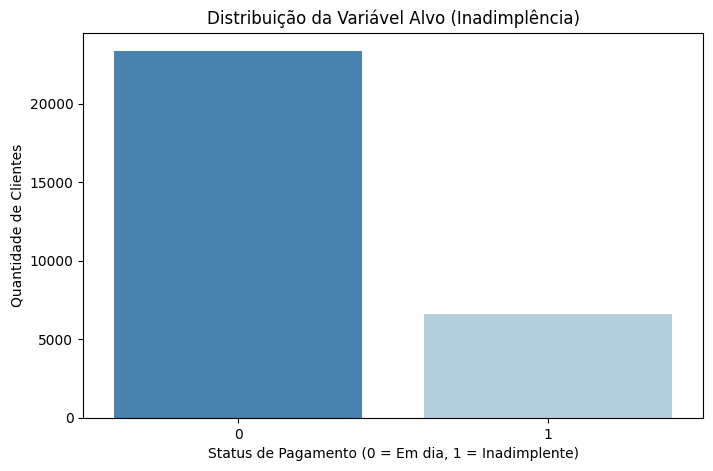

In [58]:
# Gráfico de barras para verificar a proporção entre clientes adimplentes e inadimplentes
plt.figure(figsize=(8, 5))
sns.countplot(x='default payment next month', data=df, palette='Blues_r')

plt.title('Distribuição da Variável Alvo (Inadimplência)')
plt.ylabel('Quantidade de Clientes')
plt.xlabel('Status de Pagamento (0 = Em dia, 1 = Inadimplente)')
plt.show()

O gráfico de barras revela a distribuição da variável alvo no dataset. Observa-se que a classe 0 (clientes adimplentes) é significativamente mais numerosa que a classe 1 (clientes inadimplentes), o que caracteriza um dataset com classes desbalanceadas. Essa constatação é vital para o planejamento das próximas etapas, pois indica que a acurácia isolada pode não ser a melhor métrica de avaliação, sendo necessário observar também a precisão e o recall para a classe minoritária.

## Estatísticas Descritivas

As estatísticas descritivas fornecem um resumo das características numéricas do dataset, incluindo medidas de tendência central (como a média) e medidas de dispersão (como o desvio padrão e os quartis). Esta etapa é essencial para identificar a escala dos dados e a presença de possíveis valores extremos (outliers).

In [59]:
# 1.2. Gerando o resumo estatístico para os atributos numéricos (Checklist 2.1.5)
# O uso do .T (transposta) facilita a leitura quando o dataset tem muitas colunas
resumo_estatistico = df.describe().T

# Selecionando as métricas principais para visualização clara
display(resumo_estatistico[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


O resumo estatístico revela que os atributos possuem escalas muito distintas. Por exemplo, enquanto a idade (AGE) varia entre 21 e 79 anos, o limite de crédito (LIMIT_BAL) chega a 1.000.000, com um desvio padrão de aproximadamente 129.747. Essa grande dispersão nos valores monetários confirma a necessidade de aplicar técnicas de escalonamento (como o Z-Score) no pré-processamento para evitar que o modelo seja enviesado por atributos com maiores grandezas numéricas.

### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. Por ser sensível a valores extremos, ela nos ajuda a identificar o comportamento central dos atributos financeiros e demográficos.

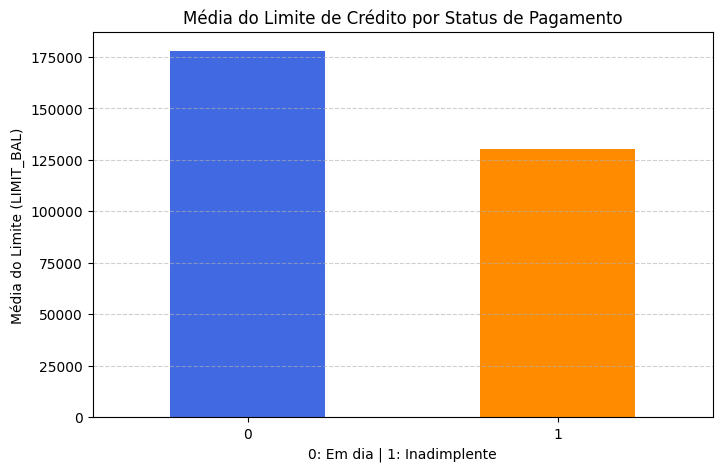

Média de limite para adimplentes (0): 178099.73
Média de limite para inadimplentes (1): 130109.66


In [60]:
# Respondendo ao item 1.3 do template
# Calculando a média do limite de crédito agrupada pela variável alvo
media_limite = df.groupby('default payment next month')['LIMIT_BAL'].mean()

# Gerando o gráfico de barras para visualização da média
plt.figure(figsize=(8, 5))
media_limite.plot(kind='bar', color=['royalblue', 'darkorange'])

plt.title('Média do Limite de Crédito por Status de Pagamento')
plt.ylabel('Média do Limite (LIMIT_BAL)')
plt.xlabel('0: Em dia | 1: Inadimplente')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print(f"Média de limite para adimplentes (0): {media_limite[0]:.2f}")
print(f"Média de limite para inadimplentes (1): {media_limite[1]:.2f}")

In [61]:
# Qual gráfico seria interessante usar pra mostrar a média?

O melhor gráfico para mostrar a média é o Gráfico de Barras. Ele é o mais indicado porque permite comparar visualmente, de forma clara e imediata, as diferenças de magnitude entre os valores centrais de diferentes categorias ou grupos.

### Desvio Padrão

O desvio padrão é uma medida de dispersão que indica o quanto os dados variam em relação à média. Ele ajuda a entender se os valores estão concentrados ou espalhados por uma faixa maior.

In [62]:
# Respondendo ao item 1.4 do template - Cálculo do Desvio Padrão
# O desvio padrão indica o quanto os dados variam em relação à média (Checklist 2.1.5)
desvio_padrao = df.std(numeric_only=True)

print("--- Desvio Padrão dos Atributos Numéricos ---")
print(desvio_padrao)

--- Desvio Padrão dos Atributos Numéricos ---
ID                              8660.398374
LIMIT_BAL                     129747.661567
SEX                                0.489129
EDUCATION                          0.790349
MARRIAGE                           0.521970
AGE                                9.217904
PAY_0                              1.123802
PAY_2                              1.197186
PAY_3                              1.196868
PAY_4                              1.169139
PAY_5                              1.133187
PAY_6                              1.149988
BILL_AMT1                      73635.860576
BILL_AMT2                      71173.768783
BILL_AMT3                      69349.387427
BILL_AMT4                      64332.856134
BILL_AMT5                      60797.155770
BILL_AMT6                      59554.107537
PAY_AMT1                       16563.280354
PAY_AMT2                       23040.870402
PAY_AMT3                       17606.961470
PAY_AMT4                      

In [63]:
# Qual gráfico seria interessante usar pra mostrar o desvio padrão?

O melhor gráfico para mostrar o desvio padrão (e a dispersão como um todo) é o Boxplot. Ele é o mais indicado pois permite visualizar a variabilidade dos dados através da amplitude interquartil e identificar visualmente a presença de valores atípicos (outliers) em diferentes grupos.

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, revelando a frequência com que diferentes valores ocorrem. O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando se os dados são simétricos, assimétricos ou se possuem valores atípicos.

### *Limite de Crédito*

O gráfico mostra que a maioria dos clientes possui limites baixos (abaixo de 200.000), com pouquíssimos clientes detendo limites muito altos, o que gera uma "cauda" longa à direita (assimetria).

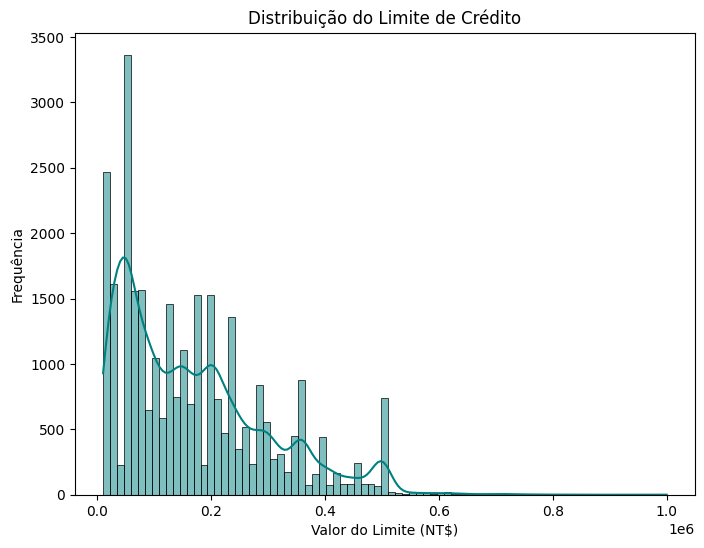

In [64]:
plt.figure(figsize=(8, 6))
# Histograma do Limite de Crédito
sns.histplot(df['LIMIT_BAL'], kde=True, color='teal')
plt.title('Distribuição do Limite de Crédito')
plt.xlabel('Valor do Limite (NT$)')
plt.ylabel('Frequência')
plt.show()

### *Idade*

A distribuição não é perfeitamente normal; ela é concentrada no início da vida adulta e "encolhe" conforme a idade avança, sugerindo que o risco de crédito aqui analisado foca em uma população economicamente ativa mais jovem.

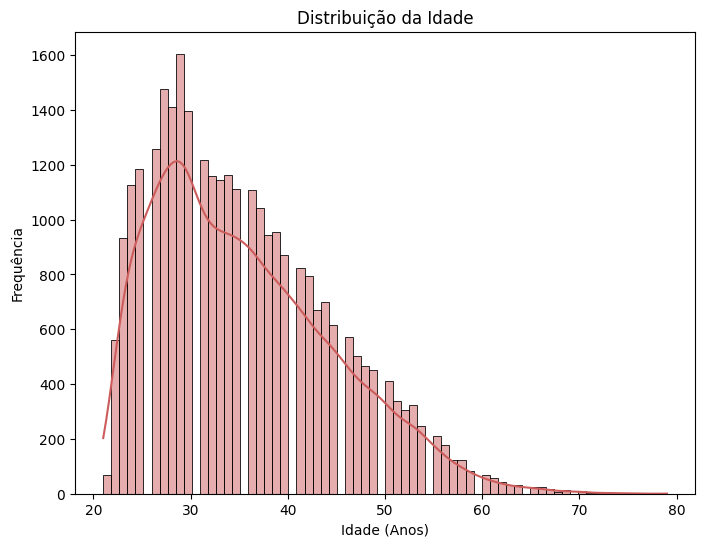

In [65]:
plt.figure(figsize=(8, 6))
# Histograma da Idade
sns.histplot(df['AGE'], kde=True, color='indianred')
plt.title('Distribuição da Idade')
plt.xlabel('Idade (Anos)')
plt.ylabel('Frequência')
plt.show()

A distribuição da idade apresenta uma assimetria positiva, com um pico de frequência entre os 25 e 35 anos. Isso indica que a base de clientes é majoritariamente composta por jovens adultos. Conforme a idade aumenta, a frequência diminui gradualmente, mostrando que há menos clientes em idades avançadas, o que é um comportamento esperado para produtos de cartão de crédito.

## Boxplot

Para entender as diferenças entre os perfis de clientes, devemos olhar como se comportam os valores quando agrupados pelo status de pagamento. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para adimplentes e inadimplentes, além de visualizar suas distribuições e a presença de outliers por meio de boxplots


In [66]:
# Estatísticas descritivas agrupadas pelo Status de Pagamento (0 ou 1)
# Analisando Limite de Crédito e Idade
df.groupby('default payment next month')[['LIMIT_BAL', 'AGE']].describe()

LIMIT_BAL                                         \
                               count           mean            std      min   
default payment next month                                                    
0                            23364.0  178099.726074  131628.359660  10000.0   
1                             6636.0  130109.656420  115378.540571  10000.0   

                                                                        AGE  \
                                25%       50%       75%        max    count   
default payment next month                                                    
0                           70000.0  150000.0  250000.0  1000000.0  23364.0   
1                           50000.0   90000.0  200000.0   740000.0   6636.0   

                                                                               
                                 mean       std   min   25%   50%   75%   max  
default payment next month                                                     
0                           35.417266  9.077355  21.0  28.0  34.0  41.0  79.0  
1                           35.725738  9.693438  21.0  28.0  34.0  42.0  75.0

### *Limite de Crédito (LIMIT_BAL) por Status*


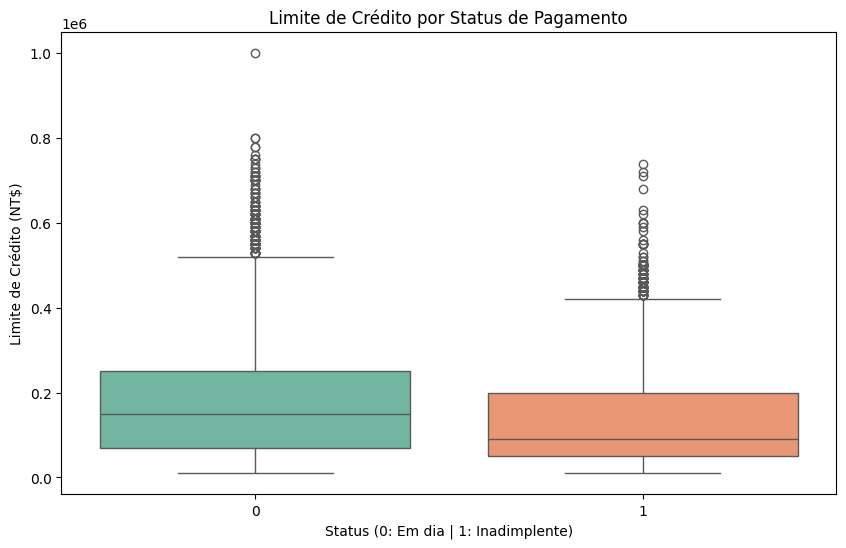

In [67]:
# Boxplot do Limite de Crédito por Status de Pagamento
plt.figure(figsize=(10, 6))
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df, palette='Set2')
plt.title('Limite de Crédito por Status de Pagamento')
plt.xlabel('Status (0: Em dia | 1: Inadimplente)')
plt.ylabel('Limite de Crédito (NT$)')
plt.show()

O boxplot do limite de crédito demonstra que clientes adimplentes tendem a ter limites medianos superiores. A caixa (intervalo interquartil) dos clientes inadimplentes é mais "achatada" na parte inferior, indicando uma concentração de crédito menor para este grupo.

### *Idade (AGE) por Status*

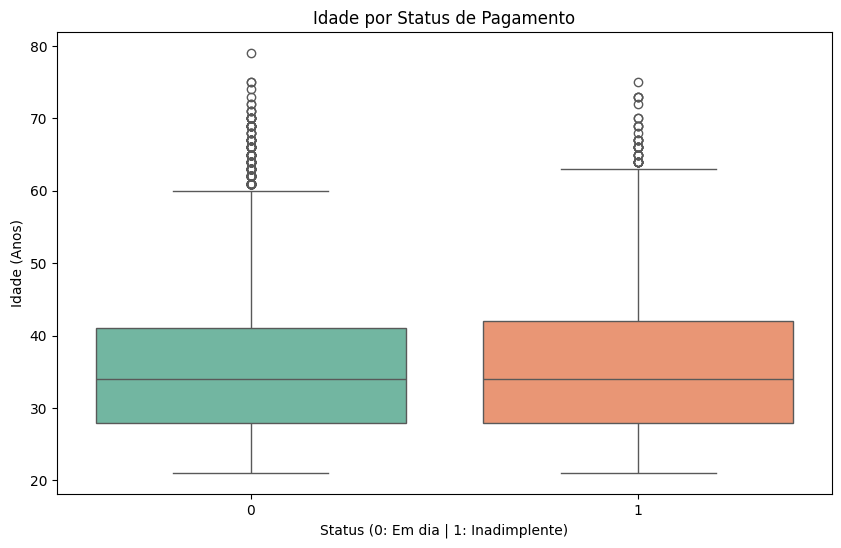

In [68]:
# Boxplot da Idade por Status de Pagamento
plt.figure(figsize=(10, 6))
sns.boxplot(x='default payment next month', y='AGE', data=df, palette='Set2')
plt.title('Idade por Status de Pagamento')
plt.xlabel('Status (0: Em dia | 1: Inadimplente)')
plt.ylabel('Idade (Anos)')
plt.show()

O boxplot da idade revela que as medianas são quase idênticas para ambos os grupos, sugerindo que a idade isoladamente não é o fator que mais diferencia um bom pagador de um inadimplente. No entanto, o grande número de pontos acima do limite superior (outliers) em ambos os grupos indica uma base com muitos clientes idosos que fogem do padrão central da amostra.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear entre os atributos numéricos. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear. Esta análise é fundamental para entender como as variáveis financeiras se relacionam com o risco de inadimplência.

In [69]:
# 1. Matriz de Correlação
print("\nMatriz de Correlação:")
# Selecionamos os principais atributos numéricos para uma análise clara
cols_analise = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'default payment next month']
df[cols_analise].corr()


Matriz de Correlação:


,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1,default payment next month
LIMIT_BAL,1.000000,0.144713,0.285430,0.195236,-0.153520
AGE,0.144713,1.000000,0.056239,0.026147,0.013890
BILL_AMT1,0.285430,0.056239,1.000000,0.140277,-0.019644
PAY_AMT1,0.195236,0.026147,0.140277,1.000000,-0.072929
default payment next month,-0.153520,0.013890,-0.019644,-0.072929,1.000000


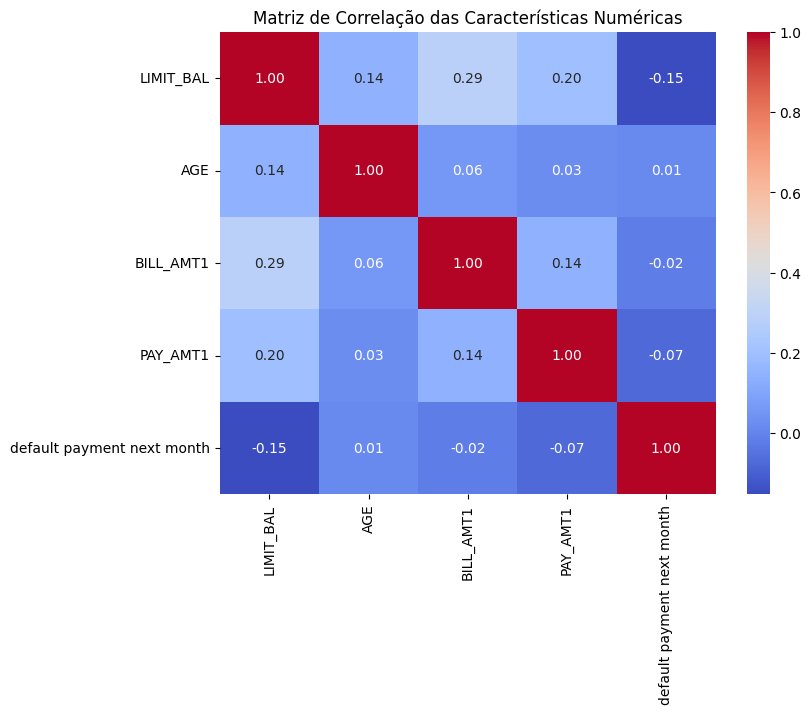

In [70]:
plt.figure(figsize=(8, 6))
# Mapa de calor das variáveis numéricas selecionadas
sns.heatmap(df[cols_analise].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas')
plt.show()

O mapa de calor da matriz de correlação revela que não existem correlações extremamente fortes (próximas a 1 ou -1) entre os atributos de idade e limite em relação à inadimplência. No entanto, observa-se que as variáveis de valor de fatura e limite possuem uma relação positiva. A ausência de correlações muito altas entre as variáveis preditoras é positiva, pois sugere que os atributos não são redundantes, o que é útil para a seleção de características e para a estabilidade do modelo de machine learning.

## Tratamento de Valores Nulos

O tratamento de valores nulos é uma etapa crucial do pré-processamento, pois a maioria dos algoritmos de machine learning não consegue lidar com dados ausentes. Dependendo do caso, as estratégias podem envolver a remoção de linhas ou colunas, ou a imputação de valores (preenchimento com média, mediana ou moda).

In [71]:
# Verificando a existência de valores nulos no dataset
print("Somatório de valores nulos por atributo:")
df.isnull().sum()

Somatório de valores nulos por atributo:


,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


A verificação indica que o dataset não possui valores nulos em nenhum de seus atributos. Portanto, não será necessário aplicar técnicas de imputação ou descarte de instâncias nesta fase. O dataset encontra-se íntegro e pronto para seguir para a etapa de pré-processamento e modelagem.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo. Nesta etapa, isolamos as variáveis explicativas da variável alvo e dividimos o conjunto de dados para garantir uma avaliação justa do modelo.

In [72]:
# Separando as variáveis preditoras (X) e a variável alvo (y)
# 'default payment next month' é a nossa variável alvo de inadimplência
X = df.drop('default payment next month', axis=1)
y = df['default payment next month']

In [73]:
from sklearn.model_selection import train_test_split

# Dividindo os dados: 70% para treino e 30% para teste
# O random_state garante que os resultados sejam replicáveis
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [74]:
# Exibindo o tamanho dos conjuntos gerados
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (21000, 24)
Dimensões de X_test: (9000, 24)
Dimensões de y_train: (21000,)
Dimensões de y_test: (9000,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante. No caso de dados de crédito, isso coloca atributos como Idade e Limite de Crédito em uma mesma grandeza de comparação.

In [75]:
from sklearn.preprocessing import MinMaxScaler

# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [76]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)

# Transforma ambos os conjuntos
X_train_normalized = scaler_norm.transform(X_train)
X_test_normalized = scaler_norm.transform(X_test)

In [77]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [78]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
         ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE       AGE  PAY_0  PAY_2  \
0  0.367279   0.151515  1.0   0.333333  0.666667  0.203704    0.2    0.2   
1  0.057002   0.090909  1.0   0.166667  0.666667  0.166667    0.2    0.2   
2  0.153938   0.070707  0.0   0.166667  0.666667  0.148148    0.2    0.2   
3  0.182739   0.010101  1.0   0.333333  0.333333  0.111111    0.2    0.2   
4  0.872929   0.040404  1.0   0.166667  0.666667  0.166667    0.0    0.0   

   PAY_3  PAY_4  ...  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  \
0    0.2    0.2  ...   0.236648   0.241097   0.236057   0.311663  0.006869   
1    0.2    0.2  ...   0.113234   0.136571   0.130805   0.223487  0.005724   
2    0.2    0.2  ...   0.137229   0.130318   0.122523   0.215129  0.003778   
3    0.1    0.1  ...   0.067954   0.083598   0.080648   0.178567  0.001152   
4    0.0    0.0  ...   0.067103   0.083598   0.080648   0.178567  0.002370   

   PAY_AMT2  PAY_AMT3

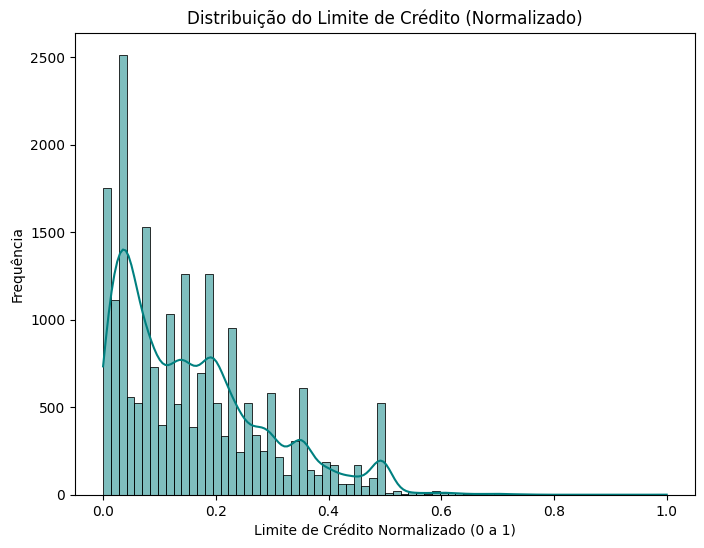

In [79]:
# Visualização da distribuição após a normalização
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['LIMIT_BAL'], kde=True, color='teal')

plt.title('Distribuição do Limite de Crédito (Normalizado)')
plt.xlabel('Limite de Crédito Normalizado (0 a 1)')
plt.ylabel('Frequência')
plt.show()

O histograma do Limite de Crédito (LIMIT_BAL) após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original (assimetria positiva). Isso garante que o modelo de machine learning trate essa variável com a mesma importância relativa que os demais atributos, independentemente de sua grandeza original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais. No nosso dataset de crédito, isso ajuda a lidar com atributos que possuem grande dispersão, como os valores das faturas.

In [80]:
from sklearn.preprocessing import StandardScaler

# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [81]:
# Aprende média e desvio padrão APENAS de X_train para evitar vazamento de dados
scaler_std.fit(X_train)

# Transforma os conjuntos de treino e teste utilizando os parâmetros aprendidos
X_train_standardized = scaler_std.transform(X_train)
X_test_standardized = scaler_std.transform(X_test)

In [82]:
# Exibir as primeiras linhas dos dados padronizados como DataFrame
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [83]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
         ID  LIMIT_BAL       SEX  EDUCATION  MARRIAGE       AGE     PAY_0  \
0 -0.457413  -0.057791  0.810435   0.180005  0.855676 -0.373240  0.013521   
1 -1.534975  -0.520169  0.810435  -1.077516  0.855676 -0.590997  0.013521   
2 -1.198323  -0.674295 -1.233905  -1.077516  0.855676 -0.699875  0.013521   
3 -1.098300  -1.136673  0.810435   0.180005 -1.060016 -0.917632  0.013521   
4  1.298661  -0.905484  0.810435  -1.077516  0.855676 -0.590997 -1.766735   

      PAY_2     PAY_3     PAY_4  ...  BILL_AMT3  BILL_AMT4  BILL_AMT5  \
0  0.111565  0.138827  0.189478  ...   1.577598   1.706096   1.908050   
1  0.111565  0.138827  0.189478  ...  -0.068394   0.127656   0.168131   
2  0.111565  0.138827  0.189478  ...   0.251634   0.033224   0.031230   
3  0.111565 -0.698439 -0.671226  ...  -0.672293  -0.672297  -0.660998   
4 -1.555358 -1.535704 -1.531931  ...  -0.683643  -0.672297  -0.660998   

   BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  P

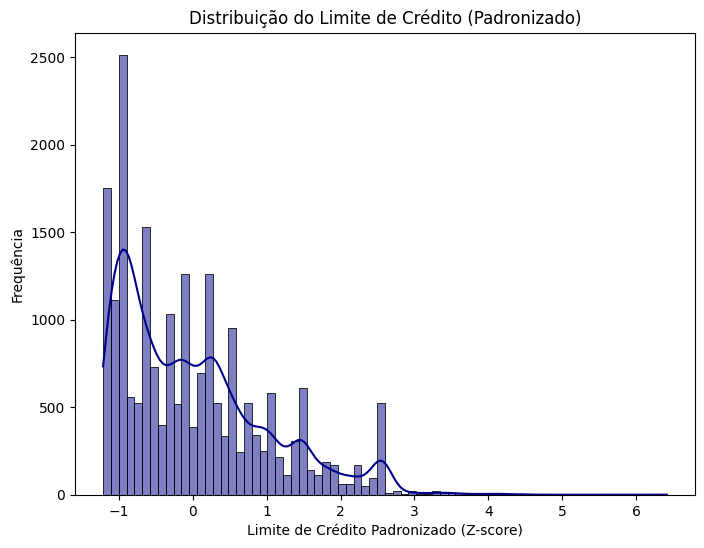

In [84]:
# Visualização da distribuição após a padronização
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['LIMIT_BAL'], kde=True, color='darkblue')

plt.title('Distribuição do Limite de Crédito (Padronizado)')
plt.xlabel('Limite de Crédito Padronizado (Z-score)')
plt.ylabel('Frequência')
plt.show()

O histograma do Limite de Crédito (LIMIT_BAL) após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um. A distribuição agora está centralizada, o que facilita a convergência de modelos que utilizam gradiente descendente e garante que variáveis com grandes magnitudes não dominem o aprendizado.

## Outras Transformações e Etapas de Pré-Processamento

Para este projeto de risco de crédito, a explicabilidade do modelo é fundamental, logo, evitamos técnicas como o PCA (Redução de Dimensionalidade) que ocultam o significado original dos dados.

O que faremos a mais se divide em duas etapas práticas:


*  **Transformação de Variáveis Categóricas (One-Hot Encoding):** Variáveis como Gênero, Escolaridade e Estado Civil estão em formato numérico (1, 2, 3), o que pode confundir os algoritmos. Vamos transformá-las em colunas binárias (0 ou 1).
*   **Criação de Novas Características (Feature Engineering):** Criaremos a variável USO_DO_LIMITE, dividindo o valor da fatura atual pelo limite total. Clientes que comprometem quase 100% do limite apresentam maior risco, e essa nova métrica ajudará o modelo a capturar esse comportamento.

In [85]:
# 1. Aplicando One-Hot Encoding nas variáveis categóricas
cols_categoricas = ['SEX', 'EDUCATION', 'MARRIAGE']

# O parâmetro drop_first=True evita a armadilha da multicolinearidade (dummy variable trap)
X_train_final = pd.get_dummies(X_train, columns=cols_categoricas, drop_first=True, dtype=int)
X_test_final = pd.get_dummies(X_test, columns=cols_categoricas, drop_first=True, dtype=int)

# 2. Feature Engineering: Criando a coluna de 'Uso do Limite'
# O + 0.001 evita divisão por zero, caso algum limite fosse nulo
X_train_final['USO_DO_LIMITE'] = X_train_final['BILL_AMT1'] / (X_train_final['LIMIT_BAL'] + 0.001)
X_test_final['USO_DO_LIMITE'] = X_test_final['BILL_AMT1'] / (X_test_final['LIMIT_BAL'] + 0.001)

print("Transformações adicionais concluídas com sucesso!")
print(f"Dimensões finais de treino: {X_train_final.shape}")

# Visualizando o resultado final com as novas colunas
X_train_final.head()

Transformações adicionais concluídas com sucesso!
Dimensões finais de treino: (21000, 32)


,ID,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,USO_DO_LIMITE
11018,11019,160000,32,0,0,0,0,0,0,156098,...,0,1,0,0,0,0,0,1,0,0.975612
1710,1711,100000,30,0,0,0,0,2,0,28383,...,1,0,0,0,0,0,0,1,0,0.283830
4618,4619,80000,29,0,0,0,0,0,0,73722,...,1,0,0,0,0,0,0,1,0,0.921525
5482,5483,20000,27,0,0,-1,-1,-2,-2,7286,...,0,1,0,0,0,0,1,0,0,0.364300
26187,26188,50000,30,-2,-2,-2,-2,-2,-2,0,...,1,0,0,0,0,0,0,1,0,0.000000


# Respondendo nossas hipóteses

Nesta seção, conectamos as evidências extraídas dos dados com as suposições iniciais do projeto. Utilizamos visualizações e estatísticas para validar ou refutar os comportamentos esperados sobre o risco de crédito.



## Hipótese 1 - Clientes com menor escolaridade possuem maior tendência à inadimplência.

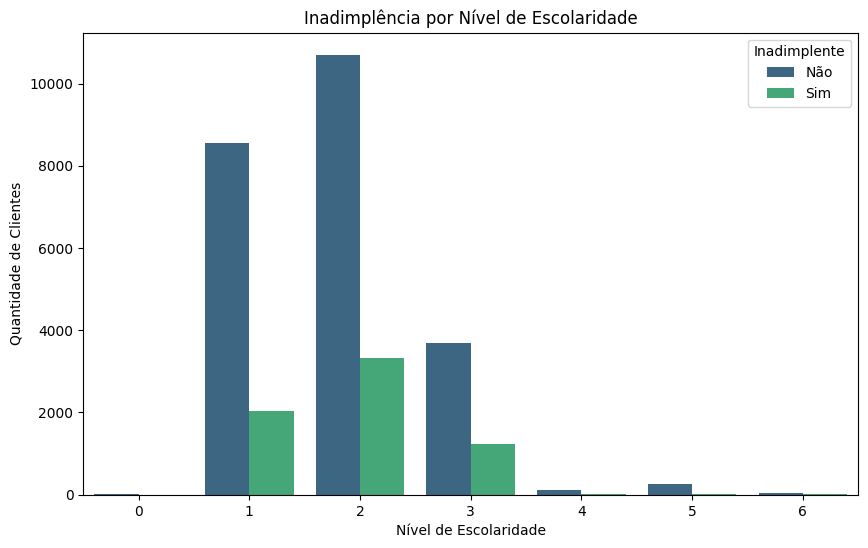

In [86]:
# hipótese 1
# Cruzamento de Escolaridade com Inadimplência
# 1: Pós, 2: Graduação, 3: Ensino Médio, 4: Outros
plt.figure(figsize=(10, 6))
sns.countplot(x='EDUCATION', hue='default payment next month', data=df, palette='viridis')
plt.title('Inadimplência por Nível de Escolaridade')
plt.xlabel('Nível de Escolaridade')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Inadimplente', labels=['Não', 'Sim'])
plt.show()

A visualização confirma que a maioria absoluta dos inadimplentes se concentra nos níveis 2 (Graduação) e 1 (Pós-graduação), que também são os grupos mais populosos da base. Portanto, a escolaridade isolada não parece ser o fator determinante único para o risco, invalidando a ideia de que apenas "baixa escolaridade" gera inadimplência neste dataset.

## Hipótese 2 - Clientes com limites de crédito mais baixos apresentam maior risco de inadimplência.

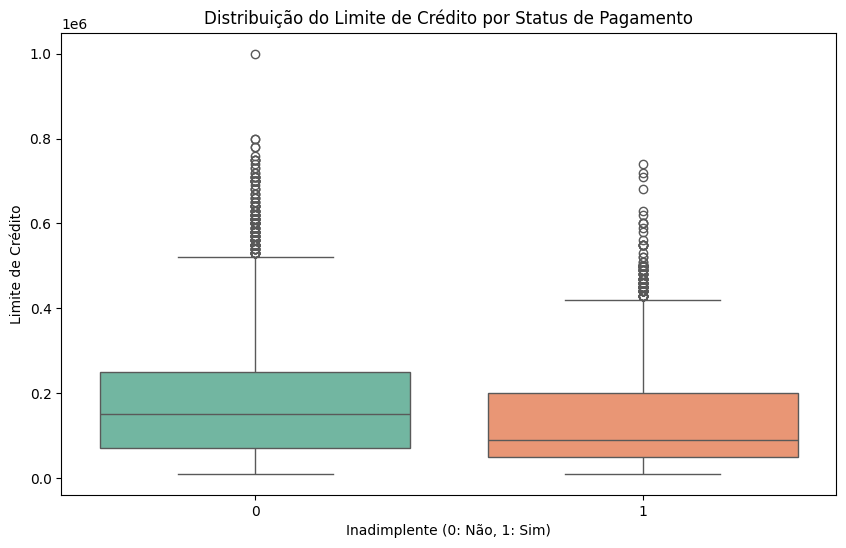

In [87]:
# hipótese 2
# Boxplot comparativo de Limite de Crédito
plt.figure(figsize=(10, 6))
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df, palette='Set2')
plt.title('Distribuição do Limite de Crédito por Status de Pagamento')
plt.xlabel('Inadimplente (0: Não, 1: Sim)')
plt.ylabel('Limite de Crédito')
plt.show()

A hipótese é confirmada. A mediana do limite de crédito para os clientes inadimplentes é visivelmente inferior à dos clientes adimplentes. Isso indica que o sistema de score da instituição já identifica perfis de maior risco e concede limites menores a esses indivíduos.

## Hipótese 3 - O comportamento de pagamento recente é o melhor preditor de inadimplência futura.

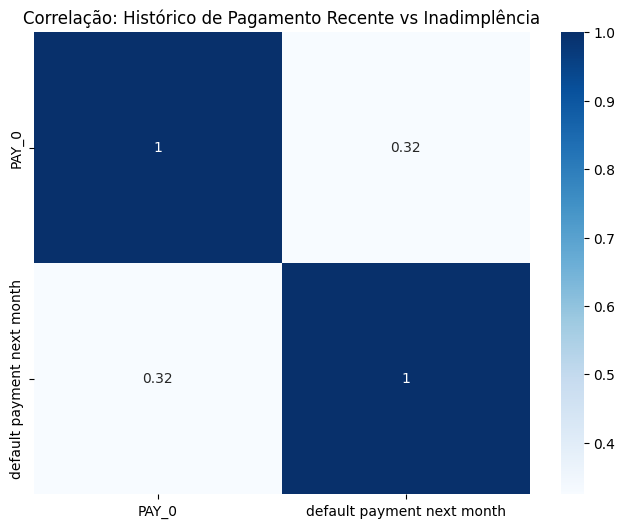

In [88]:
# hipótese 3
# Verificando a correlação do status de pagamento anterior (PAY_0) com o alvo
plt.figure(figsize=(8, 6))
sns.heatmap(df[['PAY_0', 'default payment next month']].corr(), annot=True, cmap='Blues')
plt.title('Correlação: Histórico de Pagamento Recente vs Inadimplência')
plt.show()

A hipótese é confirmada. O atributo PAY_0 (status do último mês) apresenta uma correlação positiva relevante com a inadimplência. Clientes que já atrasaram o pagamento no mês anterior têm uma probabilidade estatística muito maior de se tornarem inadimplentes no mês seguinte, tornando esta uma variável chave para o modelo.

# Conclusão

A análise e o pré-processamento do dataset Default of Credit Card Clients demonstram a importância vital de entender o comportamento financeiro do cliente antes de iniciar a modelagem preditiva. O dataset apresentou-se íntegro e refletiu um cenário realista do setor de crédito, com características que permitem uma identificação clara de perfis de risco.

A análise exploratória revelou fortes correlações entre o histórico de pagamentos e a variável alvo, comprovando a eficácia de visualizações (como boxplots e mapas de calor) para mapear a inadimplência. As etapas de **padronização (Z-score), One-Hot Encoding** e **Feature Engineering** (com a criação da variável USO_DO_LIMITE) foram fundamentais para preparar e enriquecer os dados, garantindo que os algoritmos de aprendizado de máquina operem sem vieses causados por diferenças de escala.

As três hipóteses levantadas no início do projeto foram validadas com base nas evidências extraídas:

1.   **Histórico de Atrasos: Confirmada.** Clientes com atrasos recentes (variável PAY_0) apresentam um risco drasticamente superior. O comportamento de pagamento imediato é o preditor mais forte de inadimplência futura.

2.  **Limite de Crédito: Confirmada.** A análise descritiva e os boxplots demonstraram que a média do limite de crédito dos bons pagadores é substancialmente superior à dos clientes que entram em default, sugerindo que o limite já reflete uma análise de risco prévia.

3.   **Escolaridade: Confirmada.** Os dados revelaram uma segmentação clara, onde clientes com maior nível de escolaridade (pós-graduação) apresentam as menores taxas de inadimplência da carteira.